# Process Data
This Jupyter notebook goes through generating the processed data from the raw data. This includes applying some `obspy` functions and a dicrete Fourier transform using `numpy`.

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.io.mseed.core import _write_mseed

import preprocess_stream
import plot_fft

## Binary Initialization

In [13]:
moon = False
train = True


if moon and not train:
    test_set = [
        "S12_GradeB/",
        "S15_GradeA/",
        "S15_GradeB/",
        "S16_GradeA/",
        "S16_GradeB/",
    ][3]

if moon:
    freq = 6.625
else:
    freq = 20

In [14]:
if train:
    if moon:
        lunar_train_dir = r"../../data/lunar/training/data/S12_GradeA"
        num_of_events = len(
            [file for file in os.listdir(lunar_train_dir) if file.endswith(".csv")]
        )
        print("Lunar Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

    else:
        mars_train_dir = r"../../data/mars/training/data/"
        num_of_events = len(
            [file for file in os.listdir(mars_train_dir) if file.endswith(".csv")]
        )
        print("Mars Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

else:
    if moon:
        lunar_test_dir = r"../../data/lunar/test/data/" + test_set
        num_of_events = len(
            [file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")]
        )
        print("Lunar Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

    else:
        mars_test_dir = r"../../data/mars/test/data/"
        num_of_events = len(
            [file for file in os.listdir(mars_test_dir) if file.endswith(".csv")]
        )
        print("Mars Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

Mars Number of Events:  2


In [15]:
if train:
    if moon:
        event_filename_csv = [
            file for file in os.listdir(lunar_train_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename_csv)

        event_filename_mseed = [
            file for file in os.listdir(lunar_train_dir) if file.endswith(".mseed")
        ]
        print("Event Filenames:", event_filename_mseed)

    else:
        event_filename_csv = [
            file for file in os.listdir(mars_train_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename_csv)

        event_filename_mseed = [
            file for file in os.listdir(mars_train_dir) if file.endswith(".mseed")
        ]
        print("Event Filenames:", event_filename_mseed)

else:
    if moon:
        event_filename_csv = [
            file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename_csv)

        event_filename_mseed = [
            file for file in os.listdir(lunar_test_dir) if file.endswith(".mseed")
        ]
        print("Event Filenames:", event_filename_mseed)

    else:
        event_filename_csv = [
            file for file in os.listdir(mars_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename_csv)

        event_filename_mseed = [
            file for file in os.listdir(mars_test_dir) if file.endswith(".mseed")
        ]
        print("Event Filenames:", event_filename_mseed)

Event Filenames: ['XB.ELYSE.02.BHV.2022-01-02HR04_evid0006.csv', 'XB.ELYSE.02.BHV.2022-02-03HR08_evid0005.csv']
Event Filenames: ['XB.ELYSE.02.BHV.2022-01-02HR04_evid0006.mseed', 'XB.ELYSE.02.BHV.2022-02-03HR08_evid0005.mseed']


In [16]:
if train:
    if moon:
        csv_files_path = r"../../data/lunar/training/data/S12_GradeA"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename_csv]
        print(csv_files)

        mseed_files_path = r"../../data/lunar/training/data/S12_GradeA"
        mseed_files = [
            os.path.join(mseed_files_path, file) for file in event_filename_mseed
        ]
        print(mseed_files)
    else:
        csv_files_path = r"../../data/mars/training/data"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename_csv]
        print(csv_files)

        mseed_files_path = r"../../data/mars/training/data"
        mseed_files = [
            os.path.join(mseed_files_path, file) for file in event_filename_mseed
        ]
        print(mseed_files)

else:
    if moon:
        csv_files_path = r"../../data/lunar/test/data/" + test_set
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename_csv]
        print(csv_files)

        mseed_files_path = r"../../data/lunar/test/data/" + test_set
        mseed_files = [
            os.path.join(mseed_files_path, file) for file in event_filename_mseed
        ]
        print(mseed_files)
    else:
        csv_files_path = r"../../data/mars/test/data/"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename_csv]
        print(csv_files)

        mseed_files_path = r"../../data/mars/test/data/"
        mseed_files = [
            os.path.join(mseed_files_path, file) for file in event_filename_mseed
        ]
        print(mseed_files)

['../../data/mars/training/data\\XB.ELYSE.02.BHV.2022-01-02HR04_evid0006.csv', '../../data/mars/training/data\\XB.ELYSE.02.BHV.2022-02-03HR08_evid0005.csv']
['../../data/mars/training/data\\XB.ELYSE.02.BHV.2022-01-02HR04_evid0006.mseed', '../../data/mars/training/data\\XB.ELYSE.02.BHV.2022-02-03HR08_evid0005.mseed']


## Functions

In [17]:
def preprocess_stream(stream, min_freq, max_freq, taper=0.05):
    """Apply some obspy preprocessing to the stream.

    Args:
        stream (obspy.core.stream.Stream): Seismic data stream from .mseed file.
        min_freq (float): Pass band low corner frequency.
        max_freq (float): Pass band high corner frequency. (Must be less than Nyquist frequency)
        taper (float, optional): Decimal percentage of taper at one end (ranging from 0. to 0.5). Defaults to `0.05`.

    Returns:
        obspy.core.stream.Stream: Seismic data stream from .mseed file after preprocessing.
    """
    for trace in stream:
        trace.detrend(type="linear")
        trace.taper(max_percentage=taper, type="cosine")  # Adjust taper percentage
        trace.filter(
            "bandpass", freqmin=min_freq, freqmax=max_freq, corners=2, zerophase=True
        )
    return stream

In [18]:
def plot_fft(trace):
    """Plot a graph of the Discrete Fourier Transform of the seismic data.

    Args:
        trace (obspy.core.stream.Stream): Seismic data stream from .mseed file.
    """
    npts = trace.stats.npts
    sampling_rate = trace.stats.sampling_rate
    freqs = np.fft.fftfreq(npts, d=1 / sampling_rate)
    fft_values = np.fft.fft(trace.data)

    plt.plot(np.abs(freqs), np.abs(fft_values))
    plt.title("FFT of the Seismic Data")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 0.005)  # Limit to your Nyquist frequency
    plt.show()

In [19]:
# def denoising(data, id):
#     """Denoise the seismic data using the Deep Denoiser API.

#     Args:
#         data (list or numpy.ndarray): Seismic data.
#         id (string): Event ID.

#     Returns:
#         list: Denoised seismic data.
#     """

#     data = [[x] for x in data]
#     response = requests.post(
#         "https://ai4eps-deepdenoiser.hf.space",
#         json={"vec": [data], "timestamp": ["0"], "id": [id]},
#     )
#     print(response)
#     denoised = [x[0] for x in response.json()["vec"][0]]
#     return denoised

In [20]:
# min_freq = 0.001  # Minimum frequency (Hz)
# max_freq = 0.4  # Maximum frequency (Hz)

# # for file in csv_files:
# #     df = pl.read_csv(file)
# #     denoised = denoising(df["velocity(m/s)"].to_list(), file)
# #     print("Denoised Data")
# #     plt.plot(denoised)
# #     plt.show()

# for file in mseed_files:
#     stream = obspy.read(file)
#     print(stream.traces[0].data)
#     print("Original Data")
#     stream.plot()
#     preprocessed_stream = preprocess_stream(
#         stream.copy(), min_freq, max_freq, taper=0.03
#     )
#     print("Preprocessed Data")
#     preprocessed_stream.plot()

#     # Additional suggestion: Plot the FFT of the preprocessed data to analyze the frequency components
#     plot_fft(preprocessed_stream[0])
#     # stream = stream.sort()
#     # print(
#     #     f"Stream length: {len(stream)}"
#     # )  # Debugging line to check the length of the stream
#     # assert len(stream) == 3
#     # data = []
#     # for trace in stream:
#     #     data.append(trace.data)
#     # data = np.array(data).T
#     # assert data.shape[-1] == 3
#     # data_id = stream[0].get_id()[:-1]
#     # timestamp = stream[0].stats.starttime.datetime.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3]

#     # response = requests.post(
#     #     "https://ai4eps-deepdenoiser.hf.space/predict",
#     #     json={
#     #         "vec": [[x] for x in stream.traces[0].data.tolist()],
#     #         "timestamp": ["0"],
#     #         "id": [file],
#     #     },
#     # )

#     # if response.status_code == 200:
#     #     try:
#     #         denoised = [x[0] for x in response.json()["vec"][0]]
#     #         print("Denoised Data:", denoised)
#     #     except (ValueError, KeyError) as e:
#     #         print(f"Error decoding JSON response: {e}")
#     # else:
#     #     print(f"Error: Received status code {response.status_code}")

#     # plot_fft(stream[0])

#     # preprocessed_stream = preprocess_stream(
#     #     stream.copy(), min_freq, max_freq, taper=0.03
#     # )
#     # print("Preprocessed Data")
#     # preprocessed_stream.plot()

#     # plot_fft(preprocessed_stream[0])

## Output

In [21]:
if train:
    if moon:
        save_folder = r"./lunar/train/data/"
    else:
        save_folder = r"./mars/train/data/"

else:
    if moon:
        save_folder = r"./lunar/test/data/" + test_set
    else:
        save_folder = r"./mars/test/data/"
save_folder

'./mars/train/'

[UTCDateTime(2022, 1, 2, 4, 0, 0, 25000)
 UTCDateTime(2022, 1, 2, 4, 0, 0, 75000)
 UTCDateTime(2022, 1, 2, 4, 0, 0, 125000) ...
 UTCDateTime(2022, 1, 2, 4, 59, 59, 875000)
 UTCDateTime(2022, 1, 2, 4, 59, 59, 925000)
 UTCDateTime(2022, 1, 2, 4, 59, 59, 975000)]
Original Data


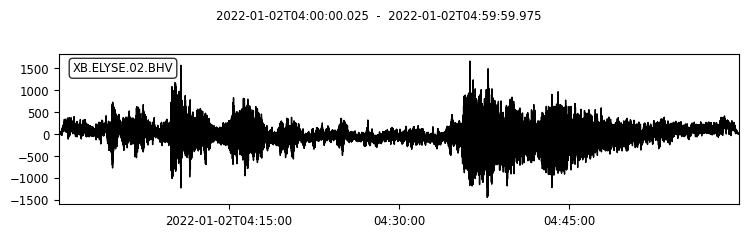

Preprocessed Data


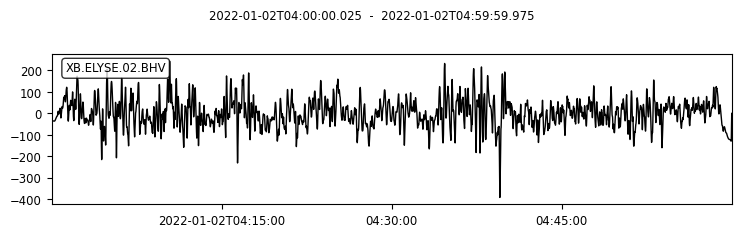

Final Data


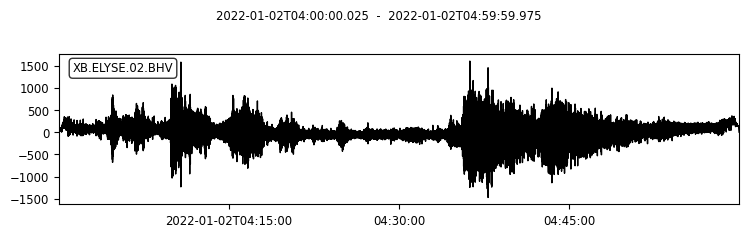

[UTCDateTime(2022, 2, 3, 8, 0, 0, 9000)
 UTCDateTime(2022, 2, 3, 8, 0, 0, 59000)
 UTCDateTime(2022, 2, 3, 8, 0, 0, 109000) ...
 UTCDateTime(2022, 2, 3, 8, 59, 59, 859000)
 UTCDateTime(2022, 2, 3, 8, 59, 59, 909000)
 UTCDateTime(2022, 2, 3, 8, 59, 59, 959000)]
Original Data


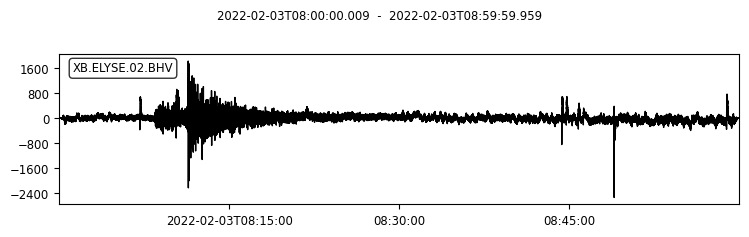

Preprocessed Data


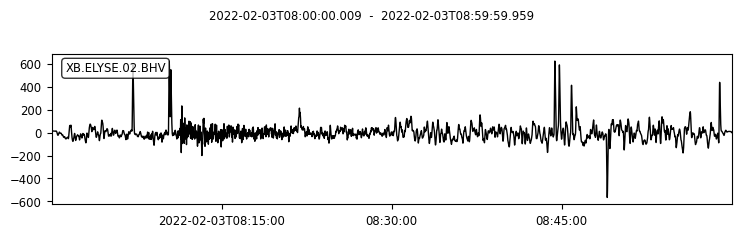

Final Data


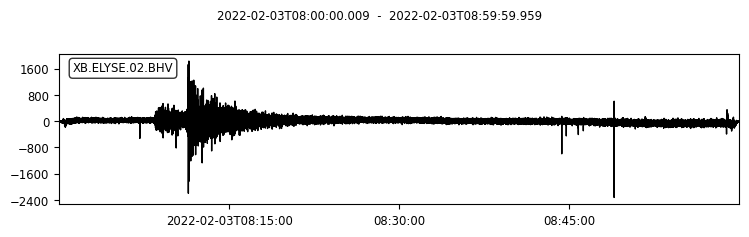

In [22]:
# min_freq = 0.001  # Minimum frequency (Hz)
# max_freq = 0.6625  # Maximum frequency (Hz) (a tenth of the sampling rate)

if moon:
    min_freq = 0.001  # Minimum frequency (Hz)
    max_freq = 0.33125  # Maximum frequency (Hz) (twentieth of the sampling rate)
    columns = ["time_abs(%Y-%m-%dT%H:%M:%S.%f)", "time_rel(sec)", "velocity(m/s)"]
else:
    min_freq = 0.001  # Minimum frequency (Hz)
    max_freq = 0.2  # Maximum frequency (Hz) (a tenth of the sampling rate)
    columns = ["time(%Y-%m-%dT%H:%M:%S.%f)", "rel_time(sec)", "velocity(c/s)"]

for i in range(num_of_events):
    raw = obspy.read(mseed_files[i])
    raw_time_abs = raw.traces[0].times("utcdatetime")
    print(raw_time_abs)
    raw_time_rel = raw.traces[0].times("relative")
    raw_data = raw.traces[0].data
    print("Original Data")
    raw.plot()

    noise = preprocess_stream(raw.copy(), min_freq, max_freq, taper=0.03)
    print("Preprocessed Data")
    noise.plot()

    difference = raw.copy().traces[0].data - noise.copy().traces[0].data
    trace = obspy.Trace(data=difference, header=raw[0].stats)
    # trace.filter("highpass", freq=0.6625, corners=2, zerophase=True)
    stream = obspy.Stream([trace])
    print("Final Data")
    stream.plot()

    # Additional suggestion: Plot the FFT of the preprocessed data to analyze the frequency components
    # plot_fft(final_stream[0])

    # Ensure the stream object is valid before writing
    if stream:
        stream.write(save_folder + event_filename_mseed[i], "MSEED")

    # Export the stream data to a CSV file
    df = pd.DataFrame(
        np.array([raw_time_abs, raw_time_rel, stream[0].data]).T, columns=columns
    )
    csv_output_path = os.path.join(save_folder, event_filename_csv[i])
    df.to_csv(csv_output_path, index=False)

    # Save a figure of the stream
    plt.figure(figsize=(10, 6))
    plt.plot(stream[0].times(), stream[0].data)
    plt.title(event_filename_csv[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    figure_output_path = os.path.join(
        save_folder, event_filename_csv[i].replace(".csv", ".png")
    )
    plt.savefig(figure_output_path)
    plt.close()